# 01 — Spanish & Finnish Data Exploration

UniMorph inflection tables: **lemma → form + tags**.  
Spanish and Finnish are compared: one Romance language with rich verbal paradigms, one agglutinative language with extreme morphological complexity.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Mac M1/M2 OpenMP fix

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

LANGS = ["spa", "fin"]
DATA_DIR = Path("../data")

### CSV and TSV
+ CSV (Comma-Separated Values) → Uses a comma (`,`) to separate data columns.
+ TSV (Tab-Separated Values) → Uses a tab (`\t`) character to separate data columns. This is preferred with language data since tabs rarely appear inside standard text fields.

And for both of them you can use `pandas.read_csv`!

In [2]:
def load_unimorph(lang: str) -> pd.DataFrame:
    path = DATA_DIR / lang / f"{lang}.tsv"
    df = pd.read_csv(
        path,
        sep="\t",
        names=["lemma", "form", "tags"],
        quoting=3,
        dtype=str,
        keep_default_na=False,
    )

    n_before = len(df)
    df = df.dropna(subset=["lemma", "form", "tags"])
    n_after = len(df)
    if n_before > n_after:
        print(f"[{lang}] dropped {n_before - n_after} malformed rows")
    return df


dfs = {lang: load_unimorph(lang) for lang in LANGS}

for lang, df in dfs.items():
    print(f"--- {lang} ---")
    print(df.shape)
    print(df.head(10))
    print()

--- spa ---
(1196245, 3)
  lemma    form                  tags
0  orar    orar                V;NFIN
1  orar  orando           V;V.CVB;PRS
2  orar   orado  V;V.PTCP;PST;MASC;SG
3  orar   orada   V;V.PTCP;PST;FEM;SG
4  orar  orados  V;V.PTCP;PST;MASC;PL
5  orar  oradas   V;V.PTCP;PST;FEM;PL
6  orar     oro        V;IND;PRS;1;SG
7  orar    oras   V;IND;PRS;2;SG;INFM
8  orar    orás   V;IND;PRS;2;SG;INFM
9  orar     ora        V;IND;PRS;3;SG

--- fin ---
(2737048, 3)
  lemma      form         tags
0  tapa      tapa     N;NOM;SG
1  tapa     tavat     N;NOM;PL
2  tapa     tavat     N;ACC;PL
3  tapa      tapa     N;ACC;SG
4  tapa     tavan     N;GEN;SG
5  tapa   tapojen     N;GEN;PL
6  tapa     tapaa     N;PRT;SG
7  tapa    tapoja     N;PRT;PL
8  tapa   tavassa  N;IN+ESS;SG
9  tapa  tavoissa  N;IN+ESS;PL



# Datasets Basic Stats
Each row represents a specific inflected word form, broken down into three core columns:
*   **`lemma`**: The dictionary or base form of the word (e.g., the infinitive of a verb or the nominative singular for a noun).
*   **`form`**: The actual surface / inflected form of the word.
*   **`tags`**: A semicolon-separated string of UniMorph morphosyntactic features.

## Morphological Tags
Tagsets follow UniMorph conventions and vary per language.

### Spanish (focus)
Spanish has rich verbal inflection (person, number, tense, mood, clitics). Example:
*   **`V;IND;PRS;1;SG`** → Verb, Indicative, Present, 1st person, Singular (e.g. *hablo* from *hablar*).
*   **`N;FEM;PL`** → Noun, Feminine, Plural (e.g. *casas* from *casa*).

### Finnish (comparison)
*   Finnish is highly agglutinative — 15 grammatical cases, extensive verb conjugation.
*   Useful high-morphology contrast: many forms per lemma and long tag strings compared to Spanish.

In [3]:
def paradigm_stats(df: pd.DataFrame, lang: str) -> dict:
    return {
        "lang": lang,
        "n_rows": len(df),
        "n_unique_lemmas": df["lemma"].nunique(),
        "n_unique_forms": df["form"].nunique(),
        "n_unique_tagsets": df["tags"].nunique(),
        "avg_forms_per_lemma": df.groupby("lemma")["form"].nunique().mean(),
    }


coverage = pd.DataFrame([paradigm_stats(df, lang) for lang, df in dfs.items()])
print(coverage)

  lang   n_rows  n_unique_lemmas  n_unique_forms  n_unique_tagsets  \
0  spa  1196245            65059          873866               164   
1  fin  2737048            57027         2523265               481   

   avg_forms_per_lemma  
0            13.753593  
1            44.625037  


spa: paradigm size stats
count    65059.0
mean        13.8
std         35.0
min          1.0
25%          2.0
50%          2.0
75%          3.0
max        198.0
Name: form, dtype: float64


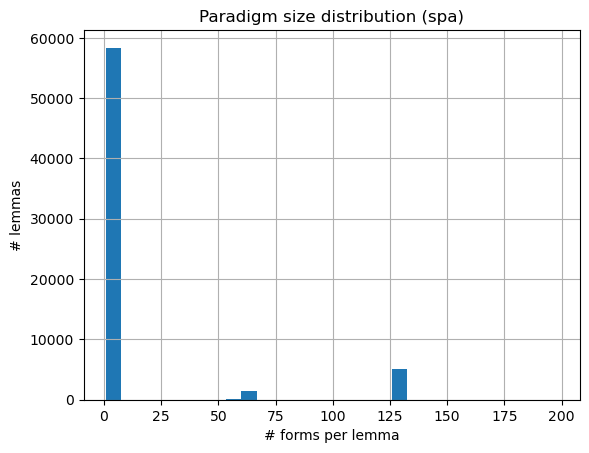

fin: paradigm size stats
count    57027.0
mean        44.6
std         43.1
min          1.0
25%         31.0
50%         31.0
75%         31.0
max        186.0
Name: form, dtype: float64


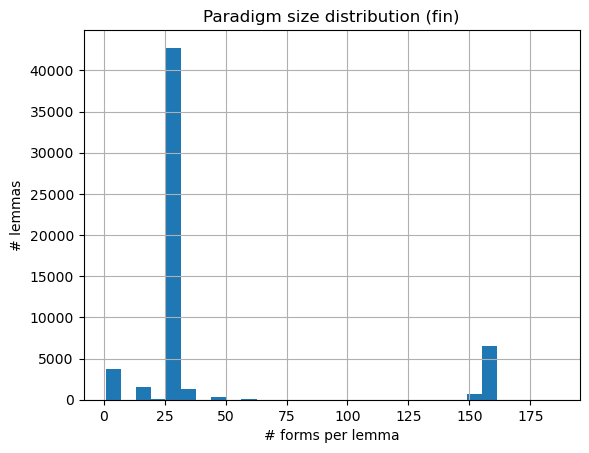

In [4]:
for lang, df in dfs.items():
    paradigm_sizes = df.groupby("lemma")["form"].nunique()
    print(f"{lang}: paradigm size stats")
    print(paradigm_sizes.describe().round(1))

    plt.figure()
    paradigm_sizes.hist(bins=30)
    plt.title(f"Paradigm size distribution ({lang})")
    plt.xlabel("# forms per lemma")
    plt.ylabel("# lemmas")
    plt.show()

In [5]:
# Most frequent individual tags (split tag bundles on ';')

def tag_frequency(df: pd.DataFrame) -> Counter:
    counter = Counter()
    for tagset in df["tags"]:
        counter.update(tagset.split(";"))
    return counter


for lang, df in dfs.items():
    freq = tag_frequency(df)
    print(f"--- {lang} top 10 individual tags ---")
    for tag, count in freq.most_common(10):
        print(f"{tag:10s} {count}")
    print()

--- spa top 10 individual tags ---
V          1048576
PL         755476
SG         737908
2          586995
PRO        496677
3          400713
IMP        384646
1          330982
ACC        284585
INFM       231700

--- fin top 10 individual tags ---
N          1304938
PL         1135518
V          1125609
SG         1034440
ACT        944059
PRS        798819
NEG        501078
PRF        493816
POS        493815
IND        406671



### Observations
1. **Spanish** is verb-heavy: most rows are `V;…` paradigms (person/number/tense/mood, often with clitics), yielding a high average number of forms per lemma.
2. **Finnish** has an even larger average paradigm size due to its agglutinative structure — 15 noun cases × number × possessive suffixes produce combinatorial explosion.
3. Finnish tag strings tend to be longer (more semicolon-separated features per row), which is visible in the token-length distribution.
4. Both languages mix POS categories (N / V / ADJ, …). Filtering to verbs only is a reasonable next-step choice for training.

# Tokenization

Models read **tokens** (subword pieces), not raw characters. We compare character length vs mT5-small subword token length on surface forms.

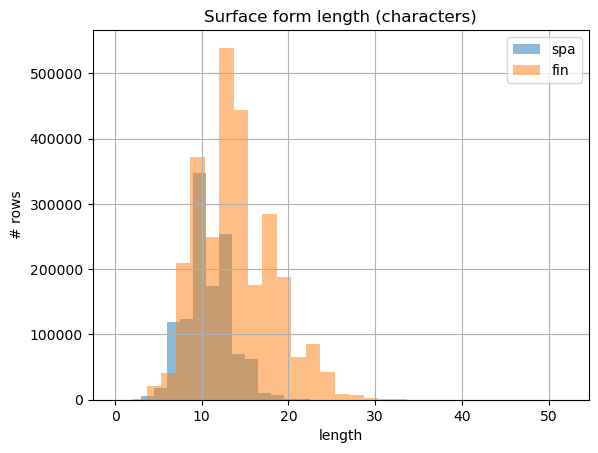

In [6]:
# Character length

for lang, df in dfs.items():
    df["form_len_chars"] = df["form"].str.len()

plt.figure()
for lang, df in dfs.items():
    df["form_len_chars"].hist(bins=30, alpha=0.5, label=lang)
plt.legend()
plt.title("Surface form length (characters)")
plt.xlabel("length")
plt.ylabel("# rows")
plt.show()

In [ ]:
# Token length (sample: full spa/fin tokenization on every row is slow)

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("google/mt5-small")
TOKEN_SAMPLE = 10_000  # per language; enough for a distribution sketch

plt.figure()
for lang, df in dfs.items():
    sample = df["form"]
    if len(sample) > TOKEN_SAMPLE:
        sample = sample.sample(TOKEN_SAMPLE, random_state=42)
    token_lens = sample.apply(lambda f: len(tokenizer.tokenize(f)))
    token_lens.hist(bins=20, alpha=0.5, label=lang)
plt.legend()
plt.title(f"Surface form length (mT5 subword tokens, n≤{TOKEN_SAMPLE}/lang)")
plt.xlabel("# tokens")
plt.ylabel("# rows")
plt.show()

/Users/falcolluc/miniconda3/envs/lora/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
